In [2]:
# https://phuijse.github.io/MachineLearningBook/contents/supervised_learning/svm.html
# https://www.svm-tutorial.com/2014/10/svm-linear-kernel-good-text-classification/
# https://docs.google.com/presentation/d/1IZZ6Ng9KG6HgS7tNy5fOHh0g4vJASR5M24tIFehAFXo/edit#slide=id.g27f40e09d8_0_113
# https://rasbt.github.io/mlxtend/#examples   -» ACÁ ESTÁ LA FN PLOT_DECISION_REGIONS

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import GridSearchCV

In [12]:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

def plot_decision_boundary(model, ax, xmin=-1.5, xmax=1.5, title=None):
    x = np.linspace(xmin, xmax, num=100)
    xx, yy = np.meshgrid(x, x)
    hiperplane = model.decision_function(np.stack((xx.ravel(), yy.ravel())).T).reshape(xx.shape)

    ax.pcolormesh(xx, yy, hiperplane, cmap='RdBu_r')
    ax.scatter(X[:, 0], X[:,1], c='k', alpha=0.5, s=20)
    if title is not None:
        ax.set_title(title)


In [4]:
# CARGAMOS DATASET

np.random.seed(12345)
X, y = make_circles(noise=0.1, factor=0.1)

non_linear_transform = lambda x : np.stack((x[:, 0], x[:, 1], x[:, 0]**2 + x[:, 1]**2)).T

PhiX = non_linear_transform(X)

In [5]:
X

array([[-1.43859311e-01,  1.83945392e-01],
       [-4.66751737e-01, -7.53059830e-01],
       [ 1.40470731e-01, -1.33770935e-01],
       [-9.21445706e-02,  2.34577457e-01],
       [-6.57564288e-01,  4.64627612e-01],
       [ 1.03758439e+00, -2.12920219e-01],
       [-4.31301039e-02,  4.29954628e-02],
       [ 4.40046673e-01, -8.59549483e-01],
       [-1.01758572e-01, -2.34016481e-01],
       [-3.44022177e-01, -9.28268580e-01],
       [-9.49861326e-01, -3.18298395e-01],
       [ 7.13466732e-01,  4.29657493e-01],
       [-1.16444637e-01,  1.08038511e-01],
       [-1.66552100e-01,  9.40651672e-01],
       [ 3.07567505e-01,  1.72566540e-01],
       [ 4.90177121e-01,  8.99390646e-01],
       [ 3.89274771e-01, -9.83461586e-01],
       [-2.33055104e-02,  9.40462917e-02],
       [-1.13428387e+00, -1.71122519e-01],
       [-1.41111888e-01, -1.77120985e-01],
       [ 9.79492385e-02,  6.27786157e-02],
       [ 9.55126439e-01, -7.33278243e-01],
       [ 9.66849602e-01, -3.46675004e-01],
       [ 1.

In [6]:
X.shape

(100, 2)

In [7]:
y

array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1])

In [9]:
PhiX

array([[-1.43859311e-01,  1.83945392e-01,  5.45314088e-02],
       [-4.66751737e-01, -7.53059830e-01,  7.84956292e-01],
       [ 1.40470731e-01, -1.33770935e-01,  3.76266895e-02],
       [-9.21445706e-02,  2.34577457e-01,  6.35172051e-02],
       [-6.57564288e-01,  4.64627612e-01,  6.48269610e-01],
       [ 1.03758439e+00, -2.12920219e-01,  1.12191638e+00],
       [-4.31301039e-02,  4.29954628e-02,  3.70881569e-03],
       [ 4.40046673e-01, -8.59549483e-01,  9.32466387e-01],
       [-1.01758572e-01, -2.34016481e-01,  6.51185202e-02],
       [-3.44022177e-01, -9.28268580e-01,  9.80033816e-01],
       [-9.49861326e-01, -3.18298395e-01,  1.00355041e+00],
       [ 7.13466732e-01,  4.29657493e-01,  6.93640339e-01],
       [-1.16444637e-01,  1.08038511e-01,  2.52316734e-02],
       [-1.66552100e-01,  9.40651672e-01,  9.12565170e-01],
       [ 3.07567505e-01,  1.72566540e-01,  1.24376981e-01],
       [ 4.90177121e-01,  8.99390646e-01,  1.04917714e+00],
       [ 3.89274771e-01, -9.83461586e-01

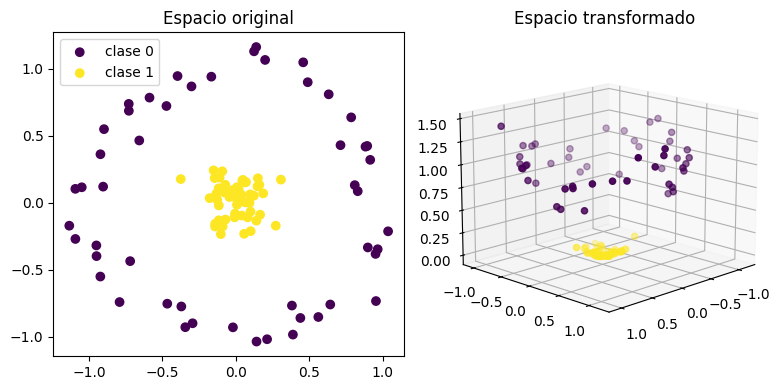

In [8]:
fig = plt.figure(figsize=(8, 4), tight_layout=True)
ax = fig.add_subplot(1, 2, 1)
for y_ in np.unique(y):
    ax.scatter(X[y==y_, 0], X[y==y_, 1], label=f'clase {y_}',
               c=y[y==y_], cmap='viridis', vmin=0, vmax=1)
ax.set_title('Espacio original')
ax.legend()
ax = fig.add_subplot(1, 2, 2, projection='3d')
for y_ in np.unique(y):
    ax.scatter(PhiX[y==y_, 0], PhiX[y==y_, 1], PhiX[y==y_, 2],
               c=y[y==y_], cmap='viridis', vmin=0, vmax=1)   # plt.cm.RdBu_r
ax.view_init(elev=15., azim=45)
ax.set_title('Espacio transformado');

In [10]:
# PRIMERO PROBAMOS UN KERNEL LINEAL

model_lin = make_pipeline(StandardScaler(),
                      SVC(kernel='linear'))

model_lin.fit(X, y);


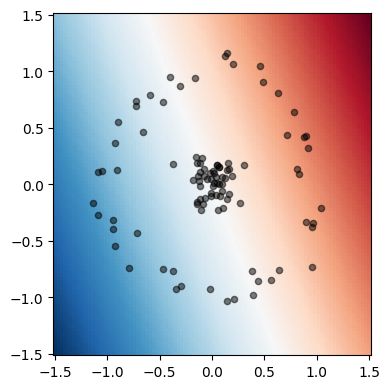

In [13]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
plot_decision_boundary(model_lin, ax)

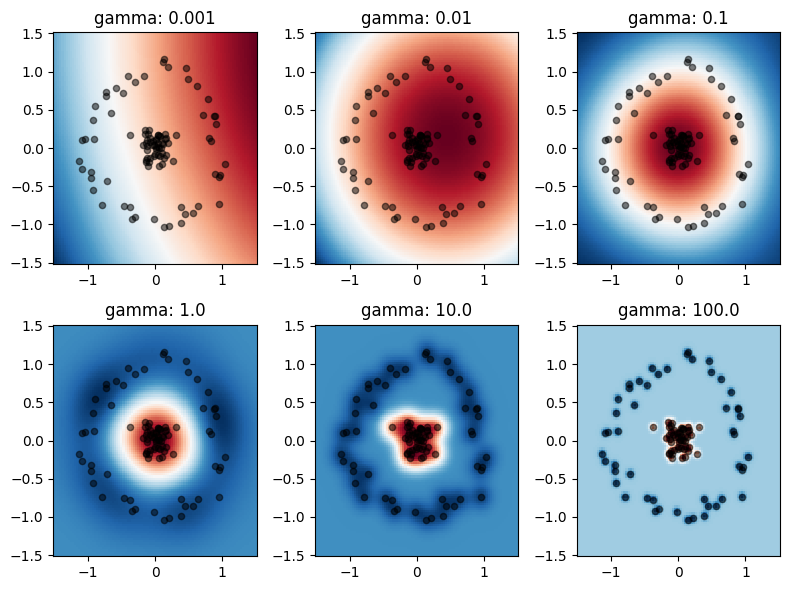

In [14]:
# AHORA CON VARIOS KERNEL GAUSSIANOS...

fig, ax = plt.subplots(2, 3, figsize=(8, 6), tight_layout=True)

for ax_, gamma_ in zip(ax.ravel(), [0.001, 0.01, 0.1, 1.0, 10., 100.]):
    model_i = make_pipeline(StandardScaler(),
                          SVC(C=1, kernel='rbf', gamma=gamma_))

    model_i.fit(X, y)
    plot_decision_boundary(model_i, ax_, title=f'gamma: {gamma_}')

In [15]:
# VEAMOS LOS PARÁMETROS

model = make_pipeline(StandardScaler(), SVC())
model.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

In [21]:
# AHORA USEMOS BÚSQUEDA X CUADRÍCULAS Y VALIDACIÓN CRUZADA PARA ENCONTRAR LOS MEJORES PARÁMETROS
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

param_grid = {'svc__C': [0.1, 1.0, 10.0, 100., 1000.],
              'svc__kernel': ['rbf'],
              'svc__gamma': [0.001, 0.01, 0.1, 1.0, 10., 100.]}


validator = GridSearchCV(model, param_grid, cv=5, scoring='f1')
validator.fit(X, y)
validator.best_params_

{'svc__C': 0.1, 'svc__gamma': 1.0, 'svc__kernel': 'rbf'}

In [22]:
validator.best_score_

np.float64(1.0)

In [18]:
model_best = validator.best_estimator_

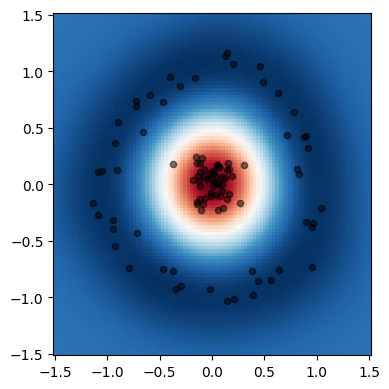

In [19]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
plot_decision_boundary(model_best, ax)